In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Activate if rendering figure
import pylustrator

pylustrator.start()

# allow cross-cell figure collection
from matplotlib import _pylab_helpers

_pylab_helpers.Gcf.destroy_all = lambda *args: ...

QApplication: invalid style override 'adwaita' passed, ignoring it.
	Available styles: Windows, Fusion


In [223]:
# Preamble
from matplotlib import pyplot as plt
import scienceplots
from machinable import get
import numpy as np
import pandas as pd
from tabulate import tabulate
from uncertainties import ufloat
from common import *

np.set_printoptions(linewidth=np.inf, suppress=True)

get(
    "machinable.index",
    "./index",
).__enter__()

plt.style.use(["science", "nature"])

# All cells random baseline

In [3]:
def fronts_nadir(components, **kwargs):
    return (
        pd.concat(components.map(lambda e: e.get_best(**kwargs)["y"])).max().to_list()
    )

## 

In [4]:
_ca1_initial = get("interface._ca1_initial")

initial_hvs = {}

for p in _ca1_initial.populations():
    num_initial = 1100
    experiments = _ca1_initial.components.filter(lambda x: p in x.label())
    nadir = fronts_nadir(experiments, region=[0, 1100])

    for experiment in experiments:
        label = experiment.label()
        cell_type, model_type = label.split("_neuron::")
        model_name = model_type[2:].split("/")[0]

        trial = experiment.context.predicate.trial

        hv = experiment.norm_hv(nadir, pf=experiment.get_best(region=[0, 1100])["y"])

        if cell_type not in initial_hvs:
            initial_hvs[cell_type] = {}

        if model_name not in initial_hvs[cell_type]:
            initial_hvs[cell_type][model_name] = []

        initial_hvs[cell_type][model_name].append(hv)

NEURON: Couldn't find: rn.hoc
 near line 0
 ^


numprocs=1


In [61]:
stash("single-cells-initial-hvs", initial_hvs)

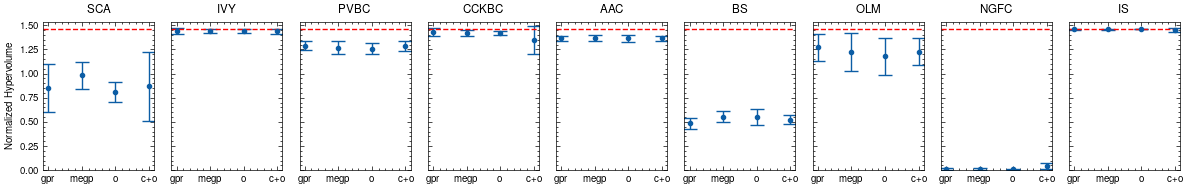

In [107]:
initial_hvs = restore("single-cells-initial-hvs")

fig, axs = plt.subplots(1, len(initial_hvs), figsize=(12, 2), sharey=True)

for ax, (cell_type, models) in zip(axs.flatten(), initial_hvs.items()):
    means = []
    stds = []
    labels = []
    for model_name, hvs in models.items():
        means.append(np.mean(hvs))
        stds.append(np.std(hvs))
        labels.append(model_name.replace("joint-", ""))

    ax.errorbar(labels, means, yerr=stds, fmt="o", capsize=5)
    ax.axhline(y=1.1**4, color="r", linestyle="--", label="Max Volume")
    ax.set_ylim(0, 1.1**4 * 1.05)
    # ax.legend()
    ax.set_title(cell_type.replace("CA1_", ""))
axs[0].set_ylabel("Normalized Hypervolume")

plt.tight_layout()
plt.show()

stash("single-cells-initial-hvs", fig)

In [108]:
summary_data = {}

for cell_type, models in initial_hvs.items():
    cell_type_key = cell_type.replace("CA1_", "")
    if cell_type_key not in summary_data:
        summary_data[cell_type_key] = {}
    for model_name, hvs in models.items():
        mean_hv = np.mean(hvs)
        std_hv = np.std(hvs)
        summary_data[cell_type_key][model_name.replace("joint-", "")] = ufloat(
            mean_hv, std_hv
        )

summary_df = pd.DataFrame(summary_data).T

summary_df.loc["Optimal"] = [ufloat(round(1.1**4, 2), 0)] * len(summary_df.columns)

summary_df["Mean Across Models"] = summary_df.apply(
    lambda row: ufloat(
        np.mean([val.nominal_value for val in row]),
        np.mean([val.std_dev for val in row]),
    ),
    axis=1,
)

summary_df = summary_df.sort_values(by="Mean Across Models", ascending=True)

display(summary_df)

latex_table = tabulate(
    summary_df.map(lambda x: f"${x:.2uL}$"), headers="keys", tablefmt="latex_raw"
)


stash("single-cells-initial-hvs.tex", latex_table)

,gpr,megp,o,c+o,Mean Across Models
NGFC,0.011+/-0.008,0.013+/-0.009,0.0081+/-0.0021,0.044+/-0.028,0.019+/-0.012
BS,0.48+/-0.05,0.55+/-0.05,0.55+/-0.08,0.52+/-0.05,0.53+/-0.06
SCA,0.85+/-0.25,0.98+/-0.14,0.81+/-0.10,0.9+/-0.4,0.88+/-0.21
OLM,1.27+/-0.14,1.22+/-0.20,1.18+/-0.19,1.23+/-0.14,1.23+/-0.17
PVBC,1.29+/-0.05,1.27+/-0.07,1.26+/-0.05,1.28+/-0.06,1.27+/-0.06
AAC,1.364+/-0.026,1.367+/-0.033,1.36+/-0.04,1.366+/-0.026,1.366+/-0.031
CCKBC,1.43+/-0.04,1.422+/-0.031,1.422+/-0.019,1.35+/-0.14,1.41+/-0.06
IVY,1.441+/-0.030,1.441+/-0.018,1.442+/-0.018,1.436+/-0.027,1.440+/-0.023
IS,1.4562+/-0.0030,1.4564+/-0.0019,1.4577+/-0.0010,1.449+/-0.018,1.455+/-0.006
Optimal,1.46+/-0,1.46+/-0,1.46+/-0,1.46+/-0,1.46+/-0


# Figure

In [ ]:
figure = plt.figure(1)

In [221]:
_ca1_sopt = get("interface._ca1_sopt")

populations = _ca1_sopt.populations()

sopts = _ca1_sopt.components

## Hypervolume convergence

In [229]:
hypervolumes = {}

for p in populations:
    experiments = sopts.filter(lambda x: p in x.label())

    nadir = fronts_nadir(experiments)
    epoch_ranges = experiments[0].epoch_ranges(from_zero=True)

    for experiment in experiments:
        label = experiment.label()
        cell_type, model_type = label.split("_neuron::")
        cell_type = cell_type.replace("CA1_", "")
        model_name = model_type[2:].split("/")[0].replace("joint-", "")
        trial = experiment.context.predicate.trial

        hypervolumes.setdefault(cell_type, {})
        hypervolumes[cell_type].setdefault(model_name, {})

        for epoch, region in enumerate(epoch_ranges):
            # if epoch % 2 != 0:
            #     continue
            hypervolumes[cell_type][model_name].setdefault(epoch, [])
            hv = experiment.norm_hv(
                nadir, pf=experiment.get_best(region=list(region))["y"]
            )
            hypervolumes[cell_type][model_name][epoch].append(hv)

stash("single-cells-hypervolumes", hypervolumes)

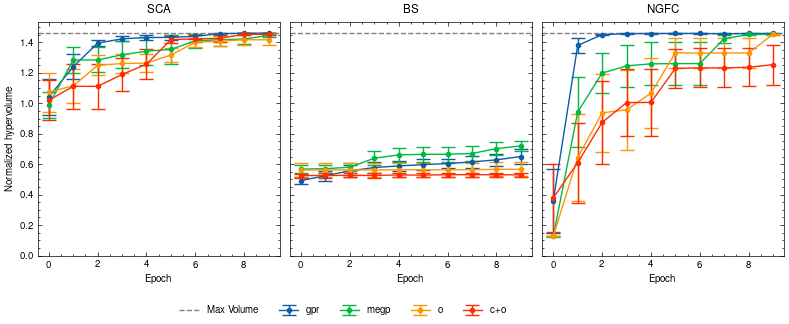

In [230]:
hypervolumes = restore("single-cells-hypervolumes")

fig, axs = plt.subplots(1, len(hypervolumes), figsize=(8, 3), sharey=True)

for ax, (cell_type, models) in zip(axs.flatten(), hypervolumes.items()):
    for model_name, epoch_hvs in models.items():
        x = []
        y = []
        y_err = []
        for epoch, hvs in epoch_hvs.items():
            x.append(int(epoch))
            y.append(np.mean(hvs))
            y_err.append(np.std(hvs) / np.sqrt(len(hvs)))

        ax.errorbar(x, y, yerr=y_err, label=model_name, fmt="-o", capsize=5)

    ax.set_xlabel("Epoch")
    ax.axhline(y=1.1**4, color="grey", linestyle="--", label="Max Volume")
    ax.set_ylim(0, 1.1**4 * 1.05)
    ax.set_title(cell_type)

axs[0].set_ylabel("Normalized hypervolume")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), bbox_to_anchor=(0.65, -0.01))
plt.tight_layout()
plt.show()

stash("single-cells-hypervolumes", fig)

## Constraint convergence

In [231]:
constraints = {"data": {}}

for p in populations:
    experiments = sopts.filter(lambda x: p in x.label())

    for experiment in experiments:
        label = experiment.label()
        cell_type, model_type = label.split("_neuron::")
        cell_type = cell_type.replace("CA1_", "")
        model_name = model_type[2:].split("/")[0].replace("joint-", "")
        trial = experiment.context.predicate.trial

        constraints["n_initial"] = experiment.num_initial_samples

        constraints["data"].setdefault(cell_type, {})
        constraints["data"][cell_type].setdefault(model_name, [])

        C = experiment.load_h5()["constraints"].to_numpy()
        feasible = np.mean(C > 0, axis=1)
        # average in chunks of a 100
        constraints["chunk_size"] = chunk_size = 500
        start = 0  # experiment.num_initial_samples
        constraints["num"] = num = len(feasible) - start
        cutoff = num - (num % chunk_size)
        end = start + cutoff
        constraints["num_"] = end
        reduce = feasible[start:end].reshape(-1, chunk_size).mean(axis=1)

        constraints["data"][cell_type][model_name].append(reduce.tolist())

stash("single-cells-constraints", constraints)

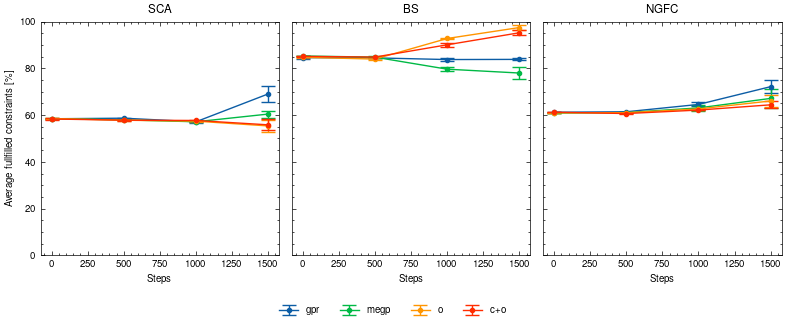

In [232]:
constraints = restore("single-cells-constraints")

fig, axs = plt.subplots(1, len(constraints["data"]), figsize=(8, 3), sharey=True)

for ax, (cell_type, models) in zip(axs.flatten(), constraints["data"].items()):
    for model_name, ccs in models.items():
        ccs = np.array(ccs) * 100
        x = range(0, constraints["num_"], constraints["chunk_size"])
        y = ccs.mean(axis=0)
        y_err = ccs.std(axis=0) / np.sqrt(len(ccs))

        ax.errorbar(x, y, yerr=y_err, label=model_name, fmt="-o", capsize=5)

    ax.set_xlabel("Steps")
    ax.vlines(
        constraints["n_initial"],
        np.min(reduce),
        np.max(reduce),
        color="grey",
        linestyle="--",
    )
    ax.set_ylim(0, 100)
    ax.set_title(cell_type)

axs[0].set_ylabel("Average fullfilled constraints [\\%]")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), bbox_to_anchor=(0.65, -0.01))
plt.tight_layout()
plt.show()

stash("single-cells-constraints", fig)

## Surrogate accuracy

In [238]:
surrogate_accuracy = {"data": {}}

for p in populations:
    experiments = sopts.filter(lambda x: p in x.label())

    yy = []
    for experiment in experiments:
        h5 = experiment.load_h5()
        yy.append(h5["predictions"].to_numpy()[experiment.num_initial_samples :])
        yy.append(h5["objectives"].to_numpy()[experiment.num_initial_samples :])
    yy = np.vstack(yy)
    yy = yy[~np.isnan(yy)]
    yy_mean = np.mean(yy, axis=0)
    yy_std = np.std(yy, axis=0)

    def norm(y):
        return (y - yy_mean) / (yy_std + 1e-9)

    for experiment in experiments:
        label = experiment.label()
        cell_type, model_type = label.split("_neuron::")
        cell_type = cell_type.replace("CA1_", "")
        model_name = model_type[2:].split("/")[0].replace("joint-", "")
        trial = experiment.context.predicate.trial

        surrogate_accuracy["n_initial"] = n_initial = experiment.num_initial_samples
        surrogate_accuracy["data"].setdefault(cell_type, {})
        surrogate_accuracy["data"][cell_type].setdefault(model_name, {})

        h5 = experiment.load_h5()
        y_pred = norm(h5["predictions"].to_numpy()[n_initial:])
        y = norm(h5["objectives"].to_numpy()[n_initial:])

        nmae = np.abs(y - y_pred)

        N = int(experiment.num_evals_per_epoch * (experiment.num_evals_per_epoch - 1))
        nmae = np.pad(nmae, ((0, N - nmae.shape[0]), (0, 0)), constant_values=np.nan)

        # average in chunks of a 100
        surrogate_accuracy["chunk_size"] = chunk_size = 100
        start = 0  # experiment.num_initial_samples
        surrogate_accuracy["num"] = num = len(nmae) - start
        cutoff = num - (num % chunk_size)
        end = start + cutoff
        surrogate_accuracy["num_"] = end
        d = surrogate_accuracy["data"][cell_type][model_name]
        for i, col in enumerate(h5["objectives"].columns):
            d.setdefault(col, [])
            reduce = np.nanmean(nmae[start:end, i].reshape(-1, chunk_size), axis=1)
            d[col].append(reduce)

stash("single-cells-surrogate-accuracy.p", surrogate_accuracy)

/tmp/ipykernel_1869844/1500208159.py:49: RuntimeWarning: Mean of empty slice
  reduce = np.nanmean(nmae[start:end, i].reshape(-1, chunk_size), axis=1)


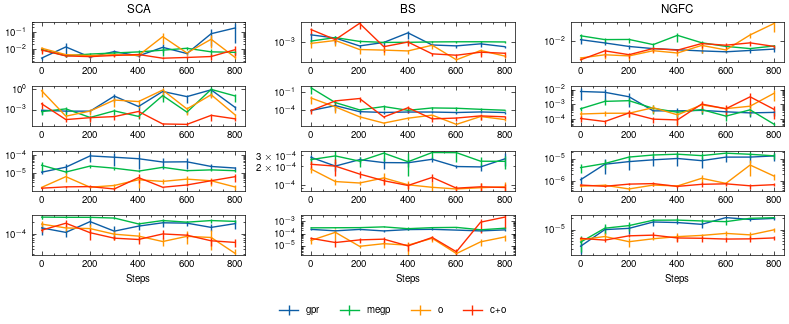

In [ ]:
surrogate_accuracy = restore("single-cells-surrogate-accuracy.p")

fig, axs = plt.subplots(
    4, len(surrogate_accuracy["data"]), figsize=(8, 3), sharey=False
)

for ax, (cell_type, models) in zip(axs.T, surrogate_accuracy["data"].items()):
    for model_name, metric in models.items():
        c = 0
        for field, mm in metric.items():
            mm = np.array(mm)
            x = np.arange(
                0, surrogate_accuracy["num_"], surrogate_accuracy["chunk_size"]
            )
            y = mm.mean(axis=0)
            y_err = mm.std(axis=0) / np.sqrt(len(mm))

            ax[c].errorbar(x, y, yerr=y_err, label=model_name)
            ax[c].set_yscale("log")
            c += 1

    ax[-1].set_xlabel("Steps")
    # ax.set_ylim(0, 100)
    ax[0].set_title(cell_type)

# axs[0].set_ylabel('Normalized Mean Absolute Error')

handles, labels = axs[0][0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), bbox_to_anchor=(0.65, -0.01))
plt.tight_layout()
plt.show()

stash("single-cells-surrogate-accuracy", fig)